# Load dataset and explore the headers and relations.
Check README.md for more information on the dataset. In this project an environment variable "DATASETS_PATH" is used in order to save the path to portfolio datasets. This datatset consits of 5 files, of which we are going to use 3 at this stage (calendar.csv, sales_train_evaluation.csv, sell_prices.csv).

In [6]:
import os
import pandas as pd

DATASETS_PATH = os.getenv("DATASETS_PATH") 

df_calendar = pd.read_csv(DATASETS_PATH + "/RetailOptimizationProject/m5-forecasting-accuracy/calendar.csv")

print(df_calendar)



            date  wm_yr_wk    weekday  wday  month  year       d  \
0     2011-01-29     11101   Saturday     1      1  2011     d_1   
1     2011-01-30     11101     Sunday     2      1  2011     d_2   
2     2011-01-31     11101     Monday     3      1  2011     d_3   
3     2011-02-01     11101    Tuesday     4      2  2011     d_4   
4     2011-02-02     11101  Wednesday     5      2  2011     d_5   
...          ...       ...        ...   ...    ...   ...     ...   
1964  2016-06-15     11620  Wednesday     5      6  2016  d_1965   
1965  2016-06-16     11620   Thursday     6      6  2016  d_1966   
1966  2016-06-17     11620     Friday     7      6  2016  d_1967   
1967  2016-06-18     11621   Saturday     1      6  2016  d_1968   
1968  2016-06-19     11621     Sunday     2      6  2016  d_1969   

      event_name_1 event_type_1  event_name_2 event_type_2  snap_CA  snap_TX  \
0              NaN          NaN           NaN          NaN        0        0   
1              NaN     

One can see here 14 columns and 1969 rows. The frame implies 1969 days with a calendar date, coding for the week (an integer number), coding for the week day, month number, two possible events and their occurances in three states of the USA. 

In [7]:
df_sell_prices = pd.read_csv(DATASETS_PATH + "/RetailOptimizationProject/m5-forecasting-accuracy/sell_prices.csv")

print(df_sell_prices)

        store_id        item_id  wm_yr_wk  sell_price
0           CA_1  HOBBIES_1_001     11325        9.58
1           CA_1  HOBBIES_1_001     11326        9.58
2           CA_1  HOBBIES_1_001     11327        8.26
3           CA_1  HOBBIES_1_001     11328        8.26
4           CA_1  HOBBIES_1_001     11329        8.26
...          ...            ...       ...         ...
6841116     WI_3    FOODS_3_827     11617        1.00
6841117     WI_3    FOODS_3_827     11618        1.00
6841118     WI_3    FOODS_3_827     11619        1.00
6841119     WI_3    FOODS_3_827     11620        1.00
6841120     WI_3    FOODS_3_827     11621        1.00

[6841121 rows x 4 columns]


One can find here the weekly prices for an item per store

In [8]:
df_sales = pd.read_csv(DATASETS_PATH + "/RetailOptimizationProject/m5-forecasting-accuracy/sales_train_evaluation.csv")

print(df_sales)

                                  id        item_id    dept_id   cat_id  \
0      HOBBIES_1_001_CA_1_evaluation  HOBBIES_1_001  HOBBIES_1  HOBBIES   
1      HOBBIES_1_002_CA_1_evaluation  HOBBIES_1_002  HOBBIES_1  HOBBIES   
2      HOBBIES_1_003_CA_1_evaluation  HOBBIES_1_003  HOBBIES_1  HOBBIES   
3      HOBBIES_1_004_CA_1_evaluation  HOBBIES_1_004  HOBBIES_1  HOBBIES   
4      HOBBIES_1_005_CA_1_evaluation  HOBBIES_1_005  HOBBIES_1  HOBBIES   
...                              ...            ...        ...      ...   
30485    FOODS_3_823_WI_3_evaluation    FOODS_3_823    FOODS_3    FOODS   
30486    FOODS_3_824_WI_3_evaluation    FOODS_3_824    FOODS_3    FOODS   
30487    FOODS_3_825_WI_3_evaluation    FOODS_3_825    FOODS_3    FOODS   
30488    FOODS_3_826_WI_3_evaluation    FOODS_3_826    FOODS_3    FOODS   
30489    FOODS_3_827_WI_3_evaluation    FOODS_3_827    FOODS_3    FOODS   

      store_id state_id  d_1  d_2  d_3  d_4  ...  d_1932  d_1933  d_1934  \
0         CA_1       CA

This frame represents the actual number of sales per day per store. Let's start our Exploratory Data Analysis (EDA) from this frame.

# How many unique stores, group of itmes and item names are there?

In [10]:
unique_stores = df_sales["store_id"].unique().tolist()
print(unique_stores)

['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']


In [11]:
unique_categories = df_sales["cat_id"].unique().tolist()
print(unique_categories)

['HOBBIES', 'HOUSEHOLD', 'FOODS']


In [12]:
unique_departments = df_sales["dept_id"].unique().tolist()
print(unique_departments)

['HOBBIES_1', 'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2', 'FOODS_1', 'FOODS_2', 'FOODS_3']


In [14]:
unique_items = df_sales["item_id"].unique().tolist()
print("Number of unique items: " + str(len(unique_items)))
print(unique_items)

Number of unique items: 3049
['HOBBIES_1_001', 'HOBBIES_1_002', 'HOBBIES_1_003', 'HOBBIES_1_004', 'HOBBIES_1_005', 'HOBBIES_1_006', 'HOBBIES_1_007', 'HOBBIES_1_008', 'HOBBIES_1_009', 'HOBBIES_1_010', 'HOBBIES_1_011', 'HOBBIES_1_012', 'HOBBIES_1_013', 'HOBBIES_1_014', 'HOBBIES_1_015', 'HOBBIES_1_016', 'HOBBIES_1_017', 'HOBBIES_1_018', 'HOBBIES_1_019', 'HOBBIES_1_020', 'HOBBIES_1_021', 'HOBBIES_1_022', 'HOBBIES_1_023', 'HOBBIES_1_024', 'HOBBIES_1_025', 'HOBBIES_1_026', 'HOBBIES_1_027', 'HOBBIES_1_028', 'HOBBIES_1_029', 'HOBBIES_1_030', 'HOBBIES_1_031', 'HOBBIES_1_032', 'HOBBIES_1_033', 'HOBBIES_1_034', 'HOBBIES_1_035', 'HOBBIES_1_036', 'HOBBIES_1_037', 'HOBBIES_1_038', 'HOBBIES_1_039', 'HOBBIES_1_040', 'HOBBIES_1_041', 'HOBBIES_1_042', 'HOBBIES_1_043', 'HOBBIES_1_044', 'HOBBIES_1_045', 'HOBBIES_1_046', 'HOBBIES_1_047', 'HOBBIES_1_048', 'HOBBIES_1_049', 'HOBBIES_1_050', 'HOBBIES_1_051', 'HOBBIES_1_052', 'HOBBIES_1_053', 'HOBBIES_1_054', 'HOBBIES_1_055', 'HOBBIES_1_056', 'HOBBIES_1_057', '

# Explore number of sales as a heat map per day in each store.
We want to make first impressions of the distributions of sales for items. This going to help us deciding for the further strategy of the forecast.

In [16]:
df_CA_1_store = df_sales[df_sales["store_id"] == "CA_1"]
print(df_CA_1_store)

                                 id        item_id    dept_id   cat_id  \
0     HOBBIES_1_001_CA_1_evaluation  HOBBIES_1_001  HOBBIES_1  HOBBIES   
1     HOBBIES_1_002_CA_1_evaluation  HOBBIES_1_002  HOBBIES_1  HOBBIES   
2     HOBBIES_1_003_CA_1_evaluation  HOBBIES_1_003  HOBBIES_1  HOBBIES   
3     HOBBIES_1_004_CA_1_evaluation  HOBBIES_1_004  HOBBIES_1  HOBBIES   
4     HOBBIES_1_005_CA_1_evaluation  HOBBIES_1_005  HOBBIES_1  HOBBIES   
...                             ...            ...        ...      ...   
3044    FOODS_3_823_CA_1_evaluation    FOODS_3_823    FOODS_3    FOODS   
3045    FOODS_3_824_CA_1_evaluation    FOODS_3_824    FOODS_3    FOODS   
3046    FOODS_3_825_CA_1_evaluation    FOODS_3_825    FOODS_3    FOODS   
3047    FOODS_3_826_CA_1_evaluation    FOODS_3_826    FOODS_3    FOODS   
3048    FOODS_3_827_CA_1_evaluation    FOODS_3_827    FOODS_3    FOODS   

     store_id state_id  d_1  d_2  d_3  d_4  ...  d_1932  d_1933  d_1934  \
0        CA_1       CA    0    0    

In [29]:
import numpy as np
arr_sales_ca1 = df_CA_1_store.filter(regex=r"^d_\d+$").to_numpy()
arr_sales_ca1[arr_sales_ca1 > 25] = 25 # naively remove the outliers
print(arr_sales_ca1)
print("Max = " + str(np.max(arr_sales_ca1)))
print("Mean = " + str(np.mean(arr_sales_ca1)))
print("Median = " + str(np.median(arr_sales_ca1)))

[[ 0  0  0 ...  3  0  1]
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  3  0  1]
 ...
 [ 0  0  0 ...  3  0  1]
 [ 0  0  0 ...  1  2  1]
 [ 0  0  0 ...  2 10  5]]
Max = 25
Mean = 1.2476802978789339
Median = 0.0


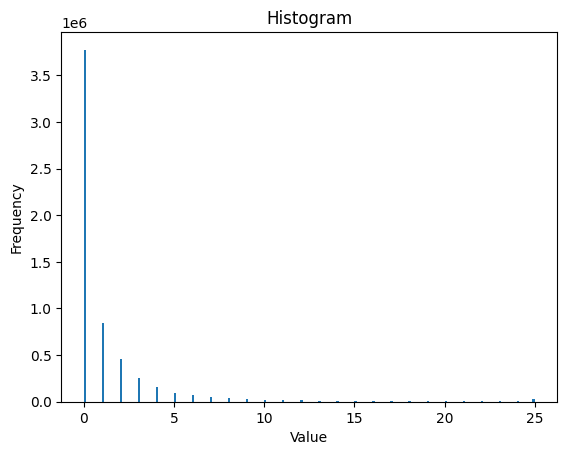

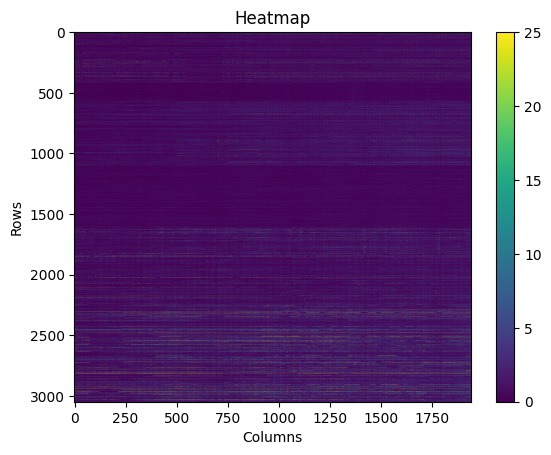

In [30]:
import matplotlib.pyplot as plt

plt.hist(arr_sales_ca1.flatten(), bins=200)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram")
plt.show()

plt.imshow(arr_sales_ca1, aspect='auto')
plt.colorbar()
plt.title("Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

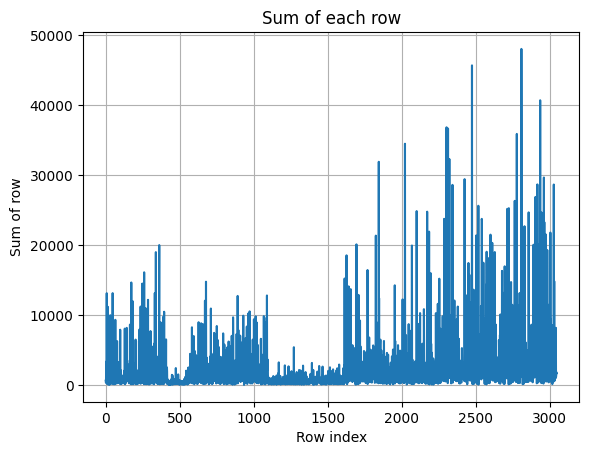

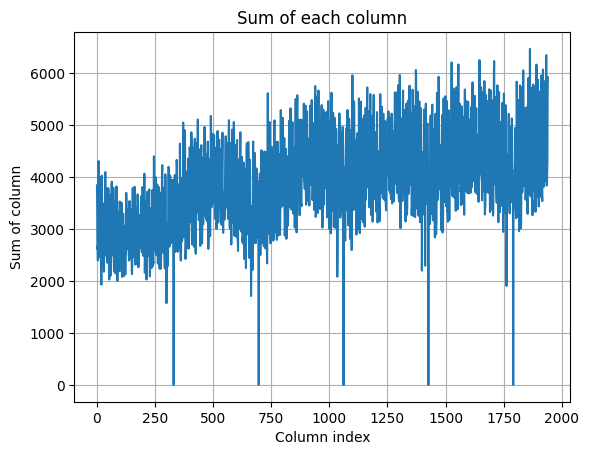

In [33]:
row_sums = arr_sales_ca1.sum(axis=1)
column_sums = arr_sales_ca1.sum(axis=0)

plt.plot(row_sums)
plt.xlabel("Row index")
plt.ylabel("Sum of row")
plt.title("Sum of each row")
plt.grid(True)
plt.show()

plt.plot(column_sums)
plt.xlabel("Column index")
plt.ylabel("Sum of column")
plt.title("Sum of each column")
plt.grid(True)
plt.show()

## Intermidiate conclusions
* There is a very strong seasonality and an obvious trend signals in the temporal dependency of the sum sales for the shop with ID "CA_1". This is very promissing because it could be possible to divide the forecasting into two steps:
    1. Temporal prediction of the cumulative sales (analizing the resulting cumulative sales over time (sum of rows in each column)).
    2. Calculating individual ratio in the sum for each item (analyzing the resulting cumulative sales over items (sum of columns in each row)).
* The first step could be done by fitting an autocorrelation model like ARIMA or SARIMA as the first intuitive approach. But also other models can be tried out.
* The second step could be done by sampling from a simple probabalistic model (like e.g. Dirichlete Multinomial Model, or sorting the items relative to its frequency in the sum of rows and fitting a polynom if the tendency holds for other shops) in order to estimate how much and how likely each item provides to the resulting sum of a column representing a time period.

# Check if the temporal pattern for cumulative sales holds for other shops.
Let's plot the sums of columns also 